# Explicabilidad del modelo de regresión logística con palabras funcionales

En este notebook se lleva a cabo el análisis de explicabilidad del mejor modelo supervisado entrenado con las 25 palabras funcionales más frecuentes, el cual es un modelo de regresión logística obtenido como resultado del experimento ejecutado en el notebook `04_mfw_robustness_experiment.ipynb`. El objetivo es entender cómo las palabras funcionales influyen en las predicciones del modelo y cuáles de ellas son más relevantes para la variable objetivo.

Para ello, se utilizan los coeficientes del modelo para identificar qué palabras funcionales tienen un mayor impacto en la predicción de la variable objetivo. Además, se visualizan estos coeficientes para facilitar su interpretación.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from whodunit_stylometry.utils.plot_utils import plot_confussion_matrix, plot_local_contributions
from whodunit_stylometry.utils.train_utils import (
    coefficients_long,
    top_coefficients_per_author,
    upper_triangle_pairs,
    transformed_features,
    local_linear_contributions,
)

## Configuración

In [2]:
SEED = 42

# Ruta a los artefactos del mejor modelo de clasificación supervisada
ML_ARTIFACTS_PATH = Path("../artifacts/best_mfw_model")

# Directorios de salida
OUTPUT_DIR = Path("../output")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGS_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, TABLES_DIR, FIGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ML_ARTIFACTS_PATH / "best_mfw_pipeline.joblib"
TRAIN_PATH = ML_ARTIFACTS_PATH / "train_mfw.parquet"
TEST_PATH = ML_ARTIFACTS_PATH / "test_mfw.parquet"
METADATA_PATH = ML_ARTIFACTS_PATH / "metadata.json"

## Carga de artefactos

In [3]:
# Carga del pipeline, los datos y los metadatos del modelo
ml_pipeline = load(MODEL_PATH)
train_fw = pd.read_parquet(TRAIN_PATH)
test_fw = pd.read_parquet(TEST_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    ml_metadata = json.load(f)

In [4]:
# Reconstrucción de los conjuntos de entrenamiento y prueba
feature_cols = [c for c in ml_metadata["feature_columns"] if c.startswith("fw_")]
target_col = ml_metadata["target"]

X_train = train_fw[feature_cols].copy()
y_train = train_fw[target_col].copy()
X_test = test_fw[feature_cols].copy()
y_test = test_fw[target_col].copy()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((83, 25), (83,), (12, 25), (12,))

In [5]:
# Resumen de los datos y el modelo
summary = pd.Series(
    {
        "modelo": ml_metadata.get("selected_model"),
        "n_features_fw": len(feature_cols),
        "n_train": len(train_fw),
        "n_test": len(test_fw),
        "target": target_col,
        "split_seed": ml_metadata.get("split_seed"),
        "f1_macro_metadata": ml_metadata.get("metrics", {}).get("test_f1_macro"),
    }
)

summary

modelo                    logreg
n_features_fw                 25
n_train                       83
n_test                        12
target               author_norm
split_seed                    42
f1_macro_metadata            1.0
dtype: object

In [6]:
clf = ml_pipeline.named_steps.get("clf")
classes = list(clf.classes_)
print("Pasos del pipeline:", list(ml_pipeline.named_steps.keys()))
print("Clases:", classes)
print("Forma de los coeficientes:", clf.coef_.shape)

Pasos del pipeline: ['imputer', 'scaler', 'clf']
Clases: ['anna_katharine_green', 'arthur_conan_doyle', 'arthur_morrison', 'gilbert_keith_chesterton', 'richard_austin_freeman', 'wilkie_collins']
Forma de los coeficientes: (6, 25)


## Resumen del rendimiento del modelo

La explicabilidad es más útil cuando se interpreta junto con el comportamiento predictivo. Como todas las predicciones son correctas, conviene revisar además las probabilidades y el margen entre la clase predicha y la segunda clase más probable.

In [7]:
y_pred = ml_pipeline.predict(X_test)
y_proba = ml_pipeline.predict_proba(X_test)

metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "n_test": len(y_test),
    }
)
metrics

accuracy     1.0
f1_macro     1.0
n_test      12.0
dtype: float64

In [8]:
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=classes))

Classification Report:
                           precision    recall  f1-score   support

    anna_katharine_green       1.00      1.00      1.00         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      1.00      1.00         2
gilbert_keith_chesterton       1.00      1.00      1.00         2
  richard_austin_freeman       1.00      1.00      1.00         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           1.00        12
               macro avg       1.00      1.00      1.00        12
            weighted avg       1.00      1.00      1.00        12



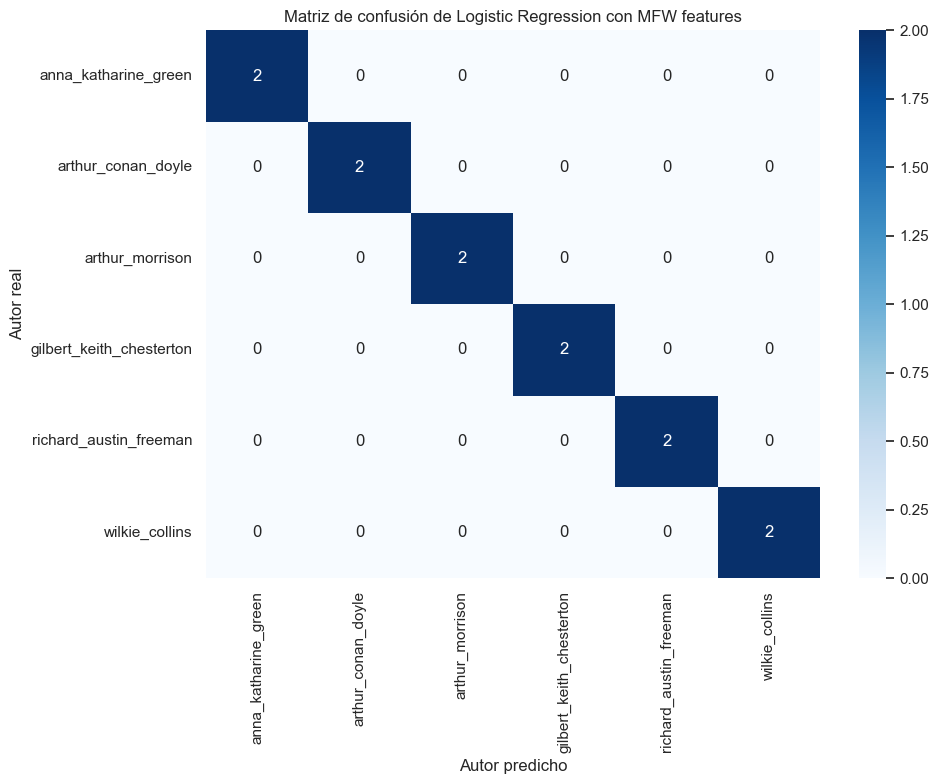

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
plot_confussion_matrix(cm=cm, labels=classes, model_name="Logistic Regression", features="MFW features")

In [10]:
proba_df = pd.DataFrame(y_proba, columns=classes, index=X_test.index)
ordered = np.sort(y_proba, axis=1)[:, ::-1]
second = ordered[:, 1] if y_proba.shape[1] > 1 else np.zeros(len(X_test))

confidence_df = pd.DataFrame(
    {
        "work": test_fw["file_name"],
        "true_author": y_test.values,
        "pred_author": y_pred,
        "proba_pred": ordered[:, 0],
        "proba_second": second,
        "margin": ordered[:, 0] - second,
        "is_correct": y_test.values == y_pred,
    },
    index=X_test.index,
).sort_values("margin")

confidence_df

,work,true_author,pred_author,proba_pred,proba_second,margin,is_correct
5,am-the_hole_in_the_wall,arthur_morrison,arthur_morrison,0.688619,0.164522,0.524097,True
3,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,0.696186,0.171868,0.524317,True
8,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,0.717890,0.187726,0.530163,True
9,raf-the_golden_pool,richard_austin_freeman,richard_austin_freeman,0.864449,0.052052,0.812397,True
2,acd-the_adventures_of_sherlock_holmes,arthur_conan_doyle,arthur_conan_doyle,0.895053,0.042499,0.852554,True
11,wc-armadale,wilkie_collins,wilkie_collins,0.934084,0.045042,0.889042,True
7,gkc-the_return_of_don_quixote,gilbert_keith_chesterton,gilbert_keith_chesterton,0.938163,0.022868,0.915295,True
10,wc-the_law_and_the_lady,wilkie_collins,wilkie_collins,0.971123,0.018240,0.952884,True
4,am-chronicles_of_martin_hewitt,arthur_morrison,arthur_morrison,0.971372,0.009528,0.961844,True
6,gkc-four_faultless_felons,gilbert_keith_chesterton,gilbert_keith_chesterton,0.976297,0.008280,0.968017,True


La tabla está ordenada de menor a mayor margen de confianza, es decir, por la diferencia entre la probabilidad asignada al autor predicho y la probabilidad del segundo autor más probable. Todas las predicciones son correctas, pero no todas tienen el mismo grado de seguridad. Las tres primeras observaciones, `arthur_morrison`, `arthur_conan_doyle` y `richard_austin_freeman`, tienen probabilidades predichas entre 0.69 y 0.72 y márgenes alrededor de 0.52–0.53. Esto indica que el modelo acierta, pero con una separación relativamente menor respecto a la segunda alternativa. Son los casos más “fronterizos” o estilísticamente menos claros dentro del test.

A partir de la observación 9, la confianza aumenta claramente y vemos que las probabilidades del autor predicho superan 0.86 y los márgenes pasan de 0.81. En los casos finales, especialmente `anna_katharine_green`, `gilbert_keith_chesterton`, `arthur_morrison` y `wilkie_collins`, el modelo asigna probabilidades superiores a 0.97, mientras que la segunda opción queda por debajo de 0.02 o cerca de ese valor. Esto sugiere que, para esas obras, el perfil de palabras funcionales es muy característico del autor según lo aprendido por la regresión logística.

Estos resultados refuerzan el buen rendimiento observado, pero conviene interpretarlos con cautela puesto que el conjunto de test contiene solo 12 obras, por lo que una precisión perfecta no garantiza necesariamente generalización robusta.

Así, la lectura más útil de esta tabla no es solo “el modelo acierta todo”, sino identificar qué textos son más ambiguos y cuáles presentan una señal estilométrica más fuerte. Los tres primeros casos serían buenos candidatos para una explicación local más detallada, revisando qué palabras funcionales empujan la decisión hacia el autor correcto y cuáles favorecen al segundo autor más probable.

In [11]:
print("Casos ambiguos por menor margen:")
low_margin_cases = confidence_df.sort_values("margin").head()
low_margin_cases

Casos ambiguos por menor margen:


,work,true_author,pred_author,proba_pred,proba_second,margin,is_correct
5,am-the_hole_in_the_wall,arthur_morrison,arthur_morrison,0.688619,0.164522,0.524097,True
3,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,0.696186,0.171868,0.524317,True
8,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,0.717890,0.187726,0.530163,True
9,raf-the_golden_pool,richard_austin_freeman,richard_austin_freeman,0.864449,0.052052,0.812397,True
2,acd-the_adventures_of_sherlock_holmes,arthur_conan_doyle,arthur_conan_doyle,0.895053,0.042499,0.852554,True


In [12]:
confidence_df.columns

Index(['work', 'true_author', 'pred_author', 'proba_pred', 'proba_second',
       'margin', 'is_correct'],
      dtype='str')

In [13]:
print("Aciertos de mayor confianza:")
high_confidence_correct_cases = (
    confidence_df[confidence_df["is_correct"]].sort_values("proba_pred", ascending=False).head()
)
high_confidence_correct_cases

Aciertos de mayor confianza:


,work,true_author,pred_author,proba_pred,proba_second,margin,is_correct
1,akg-to_the_minute,anna_katharine_green,anna_katharine_green,0.989547,0.006185,0.983362,True
0,akg-three_thousand_dollars,anna_katharine_green,anna_katharine_green,0.981753,0.006456,0.975297,True
6,gkc-four_faultless_felons,gilbert_keith_chesterton,gilbert_keith_chesterton,0.976297,0.008280,0.968017,True
4,am-chronicles_of_martin_hewitt,arthur_morrison,arthur_morrison,0.971372,0.009528,0.961844,True
10,wc-the_law_and_the_lady,wilkie_collins,wilkie_collins,0.971123,0.018240,0.952884,True


In [14]:
error_cases = confidence_df[~confidence_df["is_correct"]].sort_values("margin").head(10)

if not len(error_cases):
    print("No hay errores en el conjunto de test.")
else:
    print("Errores del modelo:")
    error_cases

No hay errores en el conjunto de test.


Los casos de margen bajo son los más útiles para investigar la ambigüedad de estilo. Los aciertos de alta confianza muestran patrones prototípicos y los errores permiten identificar las señales que empujan hacia un autor incorrecto.

## Coeficientes del modelo: explicabilidad intrínseca

En una regresión logística multiclase, cada autor tiene un vector de coeficientes. Un coeficiente positivo indica que, en el espacio de variables usado por el modelo, esa palabra funcional aumenta la evidencia relativa a favor de ese autor y, uno negativo, la reduce.

Como el pipeline incluye escalado, los coeficientes están en unidades escaladas. Por eso son adecuados para comparar importancia relativa dentro del modelo, pero no deben leerse como frecuencias brutas.

In [15]:
# Obtenemos los coeficientes del modelo para
# cada clase y los guardamos en un DataFrame
coef_df = pd.DataFrame(clf.coef_, index=classes, columns=feature_cols)
coef_df.to_csv(TABLES_DIR / "mfw_lr_coefficients_matrix.csv")
coef_df.round(3)

,fw_the,fw_and,fw_to,fw_of,fw_i,fw_a,fw_in,fw_was,fw_he,fw_that,...,fw_her,fw_as,fw_my,fw_for,fw_but,fw_at,fw_is,fw_she,fw_not,fw_have
anna_katharine_green,-0.531,-0.098,0.405,-0.290,0.118,-0.172,0.171,0.012,0.064,-0.312,...,0.480,-0.125,0.154,0.301,0.609,-0.329,-0.411,0.504,0.679,-0.020
arthur_conan_doyle,-0.191,-0.072,-0.365,-0.010,-0.094,-0.163,-0.042,-0.004,-0.255,0.214,...,-0.141,-0.513,0.405,0.227,-0.772,-0.155,0.303,-0.272,-0.320,0.747
arthur_morrison,-0.281,0.435,-0.474,-0.274,-0.149,0.106,0.263,-0.100,0.176,-0.308,...,-0.287,0.668,-0.473,0.024,0.225,0.977,-0.152,-0.255,-0.182,-0.185
gilbert_keith_chesterton,-0.038,-0.302,-0.578,0.348,-0.222,0.541,0.347,0.238,0.300,0.266,...,-0.216,-0.017,-0.549,-0.413,0.506,-0.957,0.077,-0.140,0.098,-0.557
richard_austin_freeman,0.891,0.253,0.484,0.043,0.311,0.240,-1.217,0.169,-0.057,0.426,...,-0.138,-0.227,0.055,-0.152,0.232,0.116,0.400,-0.068,-0.073,0.140
wilkie_collins,0.149,-0.216,0.528,0.183,0.036,-0.552,0.477,-0.315,-0.228,-0.286,...,0.303,0.215,0.408,0.013,-0.799,0.347,-0.217,0.231,-0.202,-0.125


Ahora, transformamos el DataFrame de coeficientes a formato largo para facilitar su análisis y añadimos la dirección en la que cada característica influye en la predicción de cada clase.

`pushes_away_from_author` indica qué palabras funcionales, al aumentar su valor, empujan la predicción hacia otras clases y no hacia el autor en cuestión. Por su parte, `pushes_toward_author` muestra las palabras que, al aumentar, favorecen la predicción de ese autor.

In [16]:
coef_long_df = coefficients_long(coef_df)
coef_long_df.to_csv(TABLES_DIR / "mfw_lr_coefficients_long.csv", index=False)
coef_long_df.head()

,author,feature,coefficient,abs_coefficient,direction
0,anna_katharine_green,fw_the,-0.531082,0.531082,pushes_away_from_author
1,arthur_conan_doyle,fw_the,-0.190671,0.190671,pushes_away_from_author
2,arthur_morrison,fw_the,-0.280659,0.280659,pushes_away_from_author
3,gilbert_keith_chesterton,fw_the,-0.037510,0.037510,pushes_away_from_author
4,richard_austin_freeman,fw_the,0.890639,0.890639,pushes_toward_author


### Palabras que más empujan hacia y contra cada autor

Analicemos más de cerca qué palabras funcionales tienen los coeficientes más altos (positivos) y más bajos (negativos) para cada autor, lo que nos dará una idea de qué características estilométricas el modelo considera más relevantes para cada uno, es decir, qué palabras funcionales acercan o alejan la predicción de cada autor.

In [17]:
top_coef_df = top_coefficients_per_author(coef_df, top_n=10)
top_coef_df.to_csv(TABLES_DIR / "mfw_best_lr_model_top_coefficients_per_author.csv", index=False)
top_coef_df

,author,feature,coefficient,direction
0,anna_katharine_green,fw_not,0.679110,pushes_toward_author
1,anna_katharine_green,fw_but,0.608602,pushes_toward_author
2,anna_katharine_green,fw_she,0.504062,pushes_toward_author
3,anna_katharine_green,fw_her,0.479945,pushes_toward_author
4,anna_katharine_green,fw_to,0.405142,pushes_toward_author
...,...,...,...,...
115,wilkie_collins,fw_with,-0.236285,pushes_away_from_author
116,wilkie_collins,fw_he,-0.227743,pushes_away_from_author
117,wilkie_collins,fw_is,-0.217296,pushes_away_from_author
118,wilkie_collins,fw_and,-0.215972,pushes_away_from_author


In [18]:
# Mostramos los top 5 positivos y negativos por autor
compact_top = top_coef_df.assign(
    rank=lambda d: d.groupby(["author", "direction"])["coefficient"].rank(method="first", ascending=False)
)
compact_top = compact_top[
    ((compact_top["direction"] == "pushes_toward_author") & (compact_top["rank"] <= 5))
    | ((compact_top["direction"] == "pushes_away_from_author") & (compact_top["rank"] >= 6))
]
compact_top.sort_values(["author", "direction", "coefficient"], ascending=[True, False, False])

,author,feature,coefficient,direction,rank
0,anna_katharine_green,fw_not,0.679110,pushes_toward_author,1.0
1,anna_katharine_green,fw_but,0.608602,pushes_toward_author,2.0
2,anna_katharine_green,fw_she,0.504062,pushes_toward_author,3.0
3,anna_katharine_green,fw_her,0.479945,pushes_toward_author,4.0
4,anna_katharine_green,fw_to,0.405142,pushes_toward_author,5.0
14,anna_katharine_green,fw_that,-0.312209,pushes_away_from_author,6.0
13,anna_katharine_green,fw_at,-0.329046,pushes_away_from_author,7.0
12,anna_katharine_green,fw_is,-0.410868,pushes_away_from_author,8.0
11,anna_katharine_green,fw_it,-0.456197,pushes_away_from_author,9.0
10,anna_katharine_green,fw_the,-0.531082,pushes_away_from_author,10.0


Estos resultados muestran qué palabras funcionales inclinan más la regresión logística hacia cada autor y cuáles la alejan. Por ejemplo, `anna_katharine_green` queda asociada positivamente con `fw_not`, `fw_but`, `fw_she` y `fw_her`, mientras que valores altos de `fw_the`, `fw_it` o `fw_is` reducen la probabilidad relativa de esa clase. En cambio, `arthur_conan_doyle` se caracteriza por coeficientes positivos en `fw_his`, `fw_have`, `fw_it` y `fw_my`, y se aleja especialmente con `fw_but`, `fw_as` y `fw_to`. Esto sugiere que el modelo no aprende “temas” literarios, sino patrones de uso gramatical y pronominal que funcionan como huellas estilométricas.

También se observan oposiciones interesantes entre autores. `fw_at` empuja fuertemente hacia `arthur_morrison`, pero aleja de `gilbert_keith_chesterton`. `fw_in` empuja hacia Chesterton, Morrison y Wilkie Collins, pero aleja con mucha fuerza de `richard_austin_freeman`. Por último, `fw_but` favorece a Anna Katharine Green y Chesterton, pero penaliza a Conan Doyle y Wilkie Collins.

Hay que interpretar los coeficientes como efectos relativos al espacio estandarizado del modelo, no como frecuencias absolutas directas. Un coeficiente positivo significa que, manteniendo el resto de variables constantes, una mayor presencia estandarizada de esa palabra aumenta la puntuación logarítmica de ese autor frente a los demás, mientras que uno negativo la reduce. Por tanto, esta tabla es útil para construir perfiles estilométricos comparados.

### Importancia global de palabras funcionales

A continuación, vamos a analizar la importancia global de cada palabra funcional en el modelo.

In [19]:
feature_importance_df = pd.DataFrame(
    {
        "feature": coef_df.columns,
        "importance_abs_max": coef_df.abs().max(axis=0).values,
        "importance_abs_mean": coef_df.abs().mean(axis=0).values,
        "importance_l2": np.sqrt((coef_df**2).sum(axis=0)).values,
        "coef_range": (coef_df.max(axis=0) - coef_df.min(axis=0)).values,
        "top_positive_author": coef_df.idxmax(axis=0).values,
        "top_negative_author": coef_df.idxmin(axis=0).values,
    }
).sort_values("importance_abs_mean", ascending=False)

feature_importance_df.to_csv(TABLES_DIR / "mfw_lr_global_coefficient_importance.csv", index=False)
feature_importance_df

,feature,importance_abs_max,importance_abs_mean,importance_l2,coef_range,top_positive_author,top_negative_author
19,fw_but,0.799003,0.523572,1.401535,1.407605,anna_katharine_green,wilkie_collins
20,fw_at,0.977114,0.480334,1.461870,1.934061,arthur_morrison,gilbert_keith_chesterton
2,fw_to,0.578101,0.472538,1.170551,1.106409,wilkie_collins,gilbert_keith_chesterton
6,fw_in,1.217017,0.419637,1.389073,1.693627,wilkie_collins,richard_austin_freeman
12,fw_his,0.884852,0.395532,1.267308,1.717879,arthur_conan_doyle,richard_austin_freeman
14,fw_with,0.858424,0.364903,1.081238,1.357317,gilbert_keith_chesterton,arthur_morrison
0,fw_the,0.890639,0.346641,1.101864,1.421722,richard_austin_freeman,anna_katharine_green
17,fw_my,0.549338,0.340937,0.939977,0.957531,wilkie_collins,gilbert_keith_chesterton
9,fw_that,0.425622,0.302026,0.756270,0.737831,richard_austin_freeman,anna_katharine_green
5,fw_a,0.552446,0.295744,0.850317,1.093580,gilbert_keith_chesterton,wilkie_collins


La tabla resume la importancia global de cada palabra funcional a partir de los coeficientes del modelo. Las variables situadas arriba son las que más ayudan a separar autores en conjunto. Destacan especialmente `fw_but`, `fw_at`, `fw_to`, `fw_in` y `fw_his`, pero no son necesariamente las palabras más frecuentes, sino las que presentan patrones más distintivos entre autores. Por ejemplo, `fw_but` tiene la mayor importancia media absoluta y separa sobre todo a `anna_katharine_green`, donde pesa positivamente, de `wilkie_collins`, donde pesa negativamente.

Algunas variables funcionan como marcadores muy polarizados. `fw_at` tiene el mayor rango de coeficientes y empuja con fuerza hacia `arthur_morrison`, pero aleja claramente de `gilbert_keith_chesterton`. Algo parecido ocurre con `fw_in`, que favorece a `wilkie_collins` y penaliza con mucha intensidad a `richard_austin_freeman`, o con `fw_his`, que caracteriza a `arthur_conan_doyle` frente a `richard_austin_freeman`. Estos casos son especialmente interpretables porque no solo indican que la palabra importa, sino también qué estilos opuestos está capturando el modelo.

También hay palabras con importancia alta pero efectos más repartidos. `fw_to`, por ejemplo, tiene una importancia media elevada, aunque su rango no es tan extremo como el de `fw_at` o `fw_in`. Esto sugiere que contribuye de forma relativamente consistente a diferenciar varios autores. En cambio, palabras como `fw_the`, `fw_with`, `fw_have` o `fw_as` parecen muy relevantes para oposiciones concretas: Freeman frente a Anna Katharine Green en `fw_the`, Chesterton frente a Morrison en `fw_with`, Conan Doyle frente a Chesterton en `fw_have`, y Morrison frente a Conan Doyle en `fw_as`.

En la parte baja aparecen palabras como `fw_you`, `fw_was`, `fw_i`, `fw_he` o `fw_for`, con valores menores en `importance_abs_mean`, `importance_l2` y `coef_range`. Esto no significa que sean inútiles, sino que su capacidad discriminativa global es más débil o más localizada. Pueden ayudar en algunos casos, pero no parecen constituir las señales estilométricas principales del clasificador.

De este modo, el modelo parece apoyarse en un pequeño grupo de palabras funcionales con fuerte poder discriminativo, especialmente conjunciones, preposiciones y pronombres. Esto encaja bien con un enfoque estilométrico donde las palabras funcionales suelen ser menos dependientes del tema y más representativas de hábitos de escritura. Aun así, la interpretación debe hacerse como una lectura relativa del modelo y del corpus usado, estos coeficientes describen cómo el clasificador separa estos autores en este conjunto de datos, no una ley general sobre el estilo literario de cada autor.

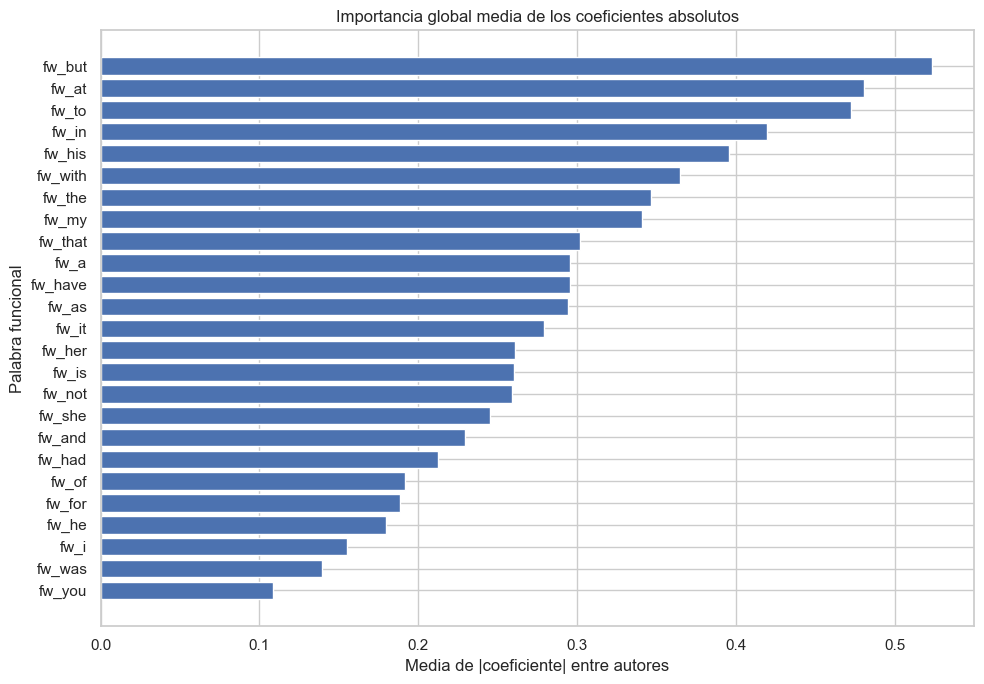

In [20]:
plt.figure(figsize=(10, 7))
plot_df = feature_importance_df.sort_values("importance_abs_mean", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance_abs_mean"])
plt.title("Importancia global media de los coeficientes absolutos")
plt.xlabel("Media de |coeficiente| entre autores")
plt.ylabel("Palabra funcional")
plt.tight_layout()
plt.savefig(FIGS_DIR / "mfw_lr_global_coef_importance.png", dpi=200, bbox_inches="tight")
plt.show()

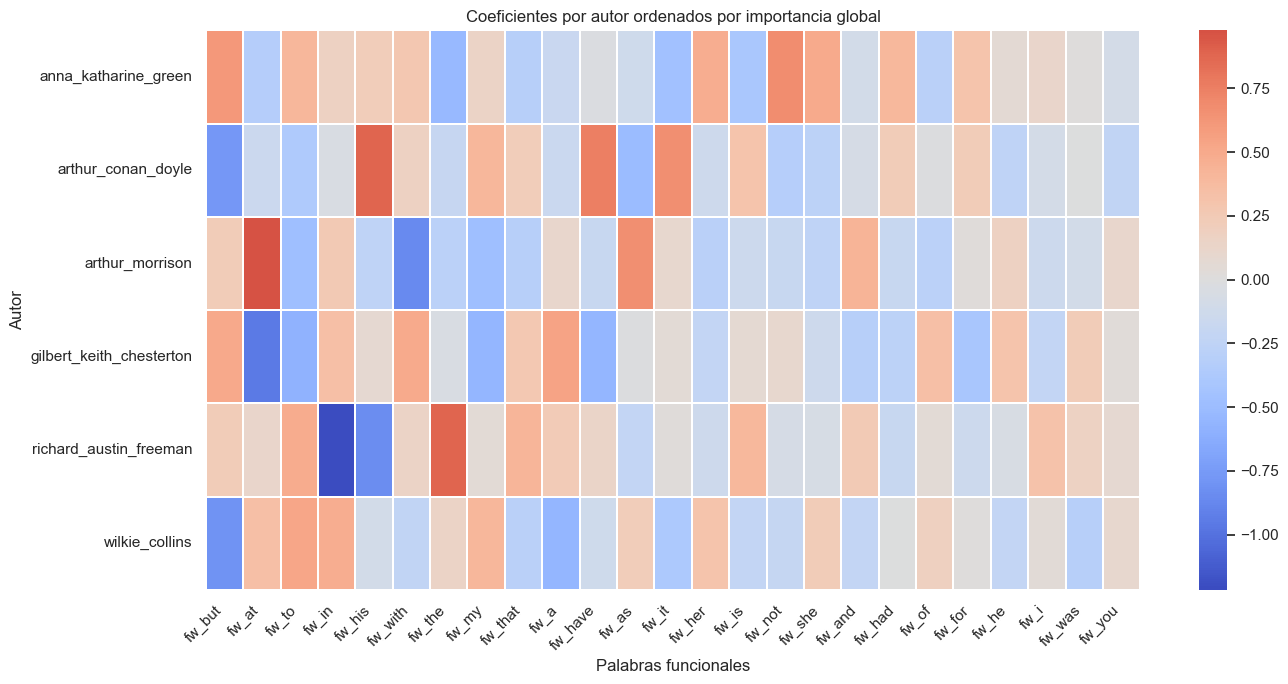

In [21]:
ordered_features = feature_importance_df["feature"].tolist()

plt.figure(figsize=(14, 7))
sns.heatmap(coef_df[ordered_features], cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Coeficientes por autor ordenados por importancia global")
plt.xlabel("Palabras funcionales")
plt.ylabel("Autor")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS_DIR / "mfw_lr_coefficients_heatmap_ordered.png", dpi=200, bbox_inches="tight")
plt.show()

## Redundancia entre palabras funcionales

Las palabras funcionales pueden estar correlacionadas. Si dos variables se mueven juntas, el coeficiente de una puede compensar o absorber parte del efecto de la otra. Esta sección detecta pares muy correlacionados para no sobreinterpretar cada coeficiente de forma aislada.

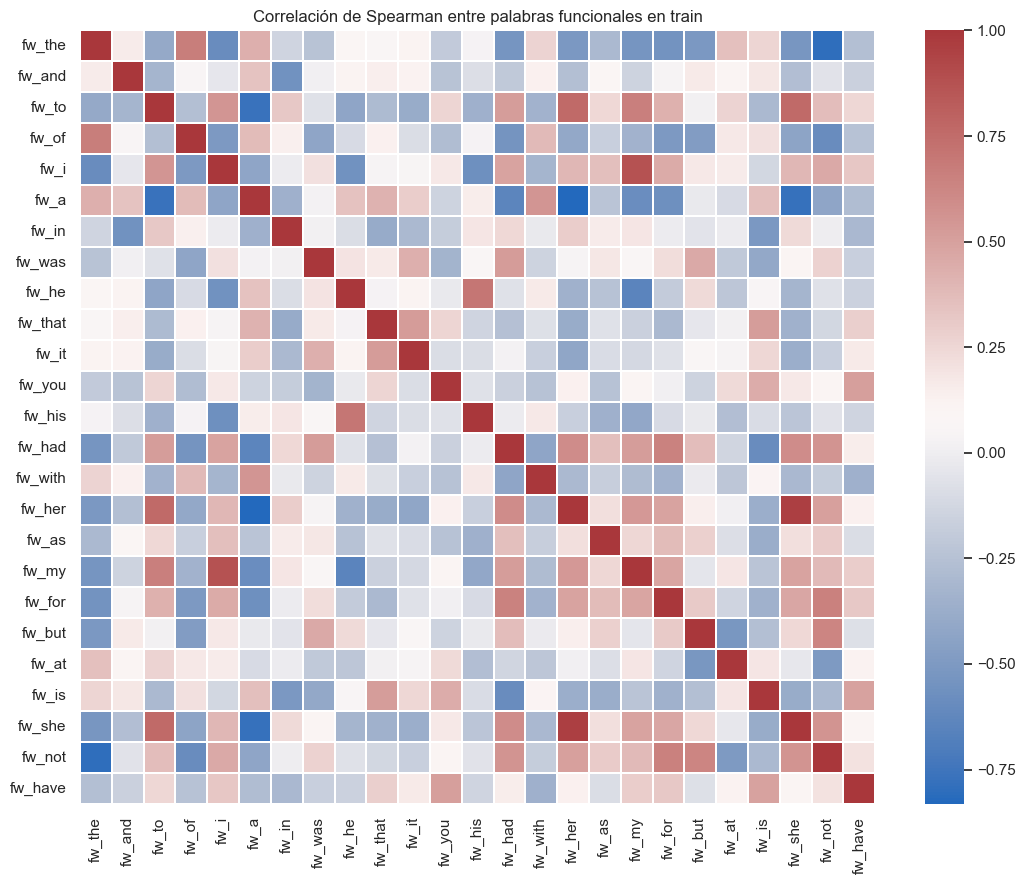

In [22]:
feature_corr = X_train[feature_cols].corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(feature_corr, cmap="vlag", linewidths=0.1)
plt.title("Correlación de Spearman entre palabras funcionales en train")
plt.tight_layout()
plt.savefig(FIGS_DIR / "mfw_feature_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
high_corr_pairs = upper_triangle_pairs(feature_corr, threshold=0.70)
high_corr_pairs.to_csv(TABLES_DIR / "mfw_highly_correlated_feature_pairs.csv", index=False)
high_corr_pairs

,feature_1,feature_2,spearman_corr,abs_corr
397,fw_her,fw_she,0.960812,0.960812
117,fw_i,fw_my,0.872256,0.872256
140,fw_a,fw_her,-0.831325,0.831325
23,fw_the,fw_not,-0.798035,0.798035
147,fw_a,fw_she,-0.775534,0.775534
55,fw_to,fw_a,-0.770245,0.770245
72,fw_to,fw_she,0.759855,0.759855
65,fw_to,fw_her,0.758658,0.758658
212,fw_he,fw_his,0.704420,0.704420


La tabla muestra pares de palabras funcionales con alta correlación de Spearman, es decir, palabras cuyas frecuencias tienden a moverse juntas, o en direcciones opuestas, entre las obras. La relación más fuerte es `fw_her`–`fw_she` con una correlación de 0.96, lo que indica que los textos con más uso relativo de `her` suelen tener también más uso de `she`. Algo parecido ocurre con `fw_i`–`fw_my` y `fw_he`–`fw_his`, asociaciones esperables porque combinan pronombres personales y posesivos relacionados gramaticalmente.

También aparecen correlaciones negativas muy marcadas. Por ejemplo, `fw_a` se correlaciona negativamente con `fw_her` y `fw_she`, y `fw_the` con `fw_not`. Esto sugiere que ciertos perfiles de uso funcional se sustituyen o compiten entre sí dentro del corpus. En términos estilométricos, estas relaciones pueden reflejar diferencias de voz narrativa, presencia de personajes femeninos, cierta construcción sintáctica o simplemente hábitos del autor asociados a determinados textos.

Desde el punto de vista del modelo, estas correlaciones son importantes porque indican redundancia entre variables. Si `fw_her` y `fw_she` aportan casi la misma señal, sus coeficientes individuales deben interpretarse con cautela ya que el modelo puede repartir la importancia entre ambas o favorecer una sobre otra según pequeñas variaciones del entrenamiento.

Por eso, esta tabla complementa el análisis de coeficientes ya que ayuda a distinguir señales realmente independientes de grupos de palabras que funcionan como bloques estilísticos correlacionados.

## Importancia por permutación

Los coeficientes permiten interpretar cómo utiliza internamente las variables la regresión logística. La importancia por permutación ofrece una perspectiva complementaria: evalúa hasta qué punto empeora el modelo cuando se desordena una variable y, por tanto, se elimina su información útil para la predicción. En un conjunto de test pequeño, esta medida puede variar bastante, pero resulta útil para comprobar si las variables con mayor peso en el modelo también tienen un impacto real en su capacidad predictiva.

In [24]:
# Calculamos la importancia por permutación en
# el conjunto de test para cada característica
perm = permutation_importance(
    ml_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=100,
    random_state=ml_metadata.get("split_seed", 42),
)

perm_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "perm_importance_mean": perm.importances_mean,
        "perm_importance_std": perm.importances_std,
    }
).sort_values("perm_importance_mean", ascending=False)

perm_df.to_csv(TABLES_DIR / "mfw_lr_permutation_importance_test.csv", index=False)
perm_df

,feature,perm_importance_mean,perm_importance_std
6,fw_in,0.106333,0.081062
19,fw_but,0.083500,0.073167
20,fw_at,0.053889,0.059698
24,fw_have,0.029000,0.045539
3,fw_of,0.023111,0.038990
0,fw_the,0.020444,0.037407
2,fw_to,0.016000,0.034150
16,fw_as,0.007111,0.024115
1,fw_and,0.000000,0.000000
8,fw_he,0.000000,0.000000


In [25]:
# Añadimos la importancia por permutación al DataFrame de
# importancia de coeficientes para comparar ambas medidas
comparison_df = (
    feature_importance_df.merge(perm_df, on="feature", how="left")
    .assign(
        coef_rank=lambda d: d["importance_abs_mean"].rank(ascending=False),
        perm_rank=lambda d: d["perm_importance_mean"].rank(ascending=False),
    )
    .sort_values("coef_rank")
)
comparison_df.to_csv(TABLES_DIR / "mfw_lr_coef_vs_permutation_importance.csv", index=False)
comparison_df

,feature,importance_abs_max,importance_abs_mean,importance_l2,coef_range,top_positive_author,top_negative_author,perm_importance_mean,perm_importance_std,coef_rank,perm_rank
0,fw_but,0.799003,0.523572,1.401535,1.407605,anna_katharine_green,wilkie_collins,0.083500,0.073167,1.0,2.0
1,fw_at,0.977114,0.480334,1.461870,1.934061,arthur_morrison,gilbert_keith_chesterton,0.053889,0.059698,2.0,3.0
2,fw_to,0.578101,0.472538,1.170551,1.106409,wilkie_collins,gilbert_keith_chesterton,0.016000,0.034150,3.0,7.0
3,fw_in,1.217017,0.419637,1.389073,1.693627,wilkie_collins,richard_austin_freeman,0.106333,0.081062,4.0,1.0
4,fw_his,0.884852,0.395532,1.267308,1.717879,arthur_conan_doyle,richard_austin_freeman,0.000000,0.000000,5.0,17.0
5,fw_with,0.858424,0.364903,1.081238,1.357317,gilbert_keith_chesterton,arthur_morrison,0.000000,0.000000,6.0,17.0
6,fw_the,0.890639,0.346641,1.101864,1.421722,richard_austin_freeman,anna_katharine_green,0.020444,0.037407,7.0,6.0
7,fw_my,0.549338,0.340937,0.939977,0.957531,wilkie_collins,gilbert_keith_chesterton,0.000000,0.000000,8.0,17.0
8,fw_that,0.425622,0.302026,0.756270,0.737831,richard_austin_freeman,anna_katharine_green,0.000000,0.000000,9.0,17.0
9,fw_a,0.552446,0.295744,0.850317,1.093580,gilbert_keith_chesterton,wilkie_collins,0.000000,0.000000,10.0,17.0


La tabla compara dos formas de medir la importancia de las palabras funcionales. Por un lado, la importancia derivada de los coeficientes de la regresión logística, por otro, la importancia por permutación, que mide cuánto cae el rendimiento cuando se desordena una variable.

La coincidencia más clara está en las primeras posiciones donde `fw_in`, `fw_but` y `fw_at` aparecen como las señales más relevantes por permutación y también estaban entre las más importantes por coeficientes. Esto refuerza la idea de que estas tres palabras no solo tienen coeficientes grandes, sino que además son efectivamente útiles para clasificar correctamente las obras.

Sin embargo, también hay discrepancias relevantes. `fw_to` es la tercera variable por importancia media de coeficientes, pero cae al puesto 7 por permutación. `fw_his`, `fw_with` y `fw_my` tienen coeficientes relativamente altos, pero su importancia por permutación es 0. Esto puede ocurrir cuando una variable está correlacionada con otras y el modelo le asigna peso, pero al permutarla aisladamente el rendimiento no cae porque otras palabras conservan una señal parecida. También puede deberse al tamaño muy pequeño del test donde, con solo 12 observaciones, la permutación tiene poca resolución y muchas variables pueden parecer irrelevantes aunque contribuyan marginalmente.

La importancia por permutación concentra la señal en pocas palabras funcionales, solo 8 de 25 tienen media positiva (`fw_in`, `fw_but`, `fw_at`, `fw_have`, `fw_of`, `fw_the`, `fw_to`, `fw_as`), mientras que las demás aparecen con 0. Entre ellas, `fw_in` es la más influyente según permutación, aunque por coeficientes ocupaba el cuarto lugar. Esto sugiere que, en los ejemplos de test, alterar `fw_in` afecta especialmente a decisiones concretas, probablemente por su papel en la separación de `wilkie_collins` frente a `richard_austin_freeman`. También llama la atención `fw_of`, que tiene un coeficiente global modesto, pero sube al quinto puesto por permutación, por lo que puede ser una variable menos llamativa en magnitud, pero útil en casos específicos del test.

La lectura más prudente es que los coeficientes ofrecen una visión estructural e interpretativa del modelo, mientras que la permutación ofrece una visión empírica del impacto predictivo sobre este test concreto. Cuando ambas coinciden, como en `fw_in`, `fw_but` y `fw_at`, la evidencia es más sólida. Cuando divergen, no significa necesariamente que una medida sea incorrecta ya que puede indicar redundancia entre variables, dependencia del conjunto de test o inestabilidad por el bajo número de muestras. Por eso, esta tabla enriquece el análisis al separar las palabras que el modelo pondera mucho de aquellas cuya alteración realmente cambia el rendimiento observado.

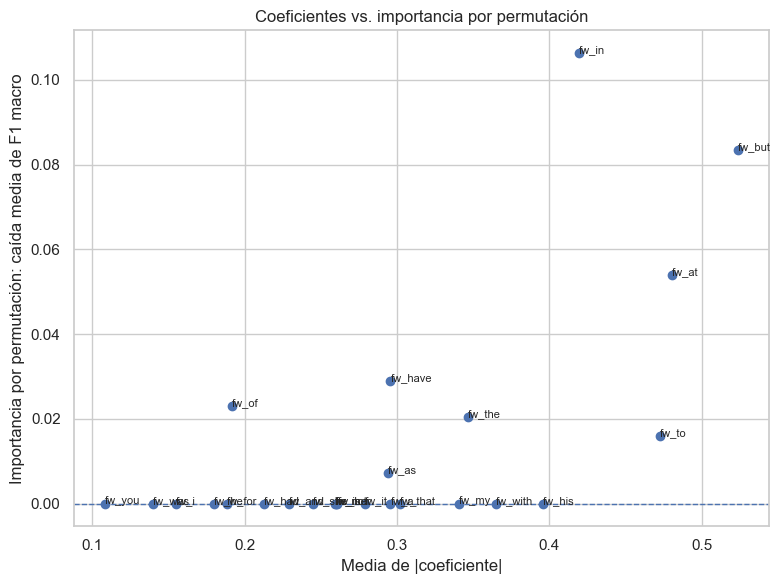

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(comparison_df["importance_abs_mean"], comparison_df["perm_importance_mean"])
for _, row in comparison_df.iterrows():
    plt.annotate(row["feature"], (row["importance_abs_mean"], row["perm_importance_mean"]), fontsize=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Coeficientes vs. importancia por permutación")
plt.xlabel("Media de |coeficiente|")
plt.ylabel("Importancia por permutación: caída media de F1 macro")
plt.tight_layout()
plt.savefig(FIGS_DIR / "mfw_lr_coef_vs_permutation.png", dpi=200, bbox_inches="tight")
plt.show()

## Explicación local de una obra concreta

Para una regresión logística, la contribución lineal de una característica a una clase se puede aproximar como:

$$\text{contribución}_{j,k} = x_j \cdot \beta_{k,j}$$

donde $x_j$ es el valor transformado de la característica y $\beta_{k,j}$ es el coeficiente de la clase $k$. Esta explicación local ayuda a responder por qué una obra concreta fue asignada a un autor.

Cuando hablamos de valor transformado, nos referimos a la versión estandarizada de la variable que el modelo realmente utiliza y que resulta de aplicarle las transformaciones del pipeline (escalado, etc.).

In [27]:
X_test_model_space = transformed_features(ml_pipeline, X_test, feature_cols)

# Elegimos la obra más incierta: menor margen entre la primera y segunda clase.
instance_id = confidence_df.index[0]
work = confidence_df.loc[instance_id, "work"]
predicted_author = confidence_df.loc[instance_id, "pred_author"]
true_author = confidence_df.loc[instance_id, "true_author"]

print(f"Instance ID: {instance_id}\nWork: {work}\nTrue Author: {true_author}\nPredicted Author: {predicted_author}")

local_df = local_linear_contributions(X_test_model_space, coef_df, instance_id, predicted_author)
local_df.to_csv(TABLES_DIR / "mfw_lr_local_explanation_most_uncertain.csv", index=False)
local_df

Instance ID: 5
Work: am-the_hole_in_the_wall
True Author: arthur_morrison
Predicted Author: arthur_morrison


,feature,x_transformed,coefficient,contribution,abs_contribution
14,fw_with,1.916673,-0.858424,-1.645318,1.645318
20,fw_at,1.190886,0.977114,1.163630,1.163630
16,fw_as,0.971532,0.667580,0.648575,0.648575
3,fw_of,-2.227100,-0.274293,0.610879,0.610879
2,fw_to,-1.231095,-0.474229,0.583821,0.583821
1,fw_and,1.183343,0.434584,0.514262,0.514262
24,fw_have,-2.449622,-0.184993,0.453162,0.453162
21,fw_is,-1.517095,-0.151509,0.229853,0.229853
6,fw_in,-0.617605,0.263442,-0.162703,0.162703
13,fw_had,-0.694483,-0.185966,0.129150,0.129150


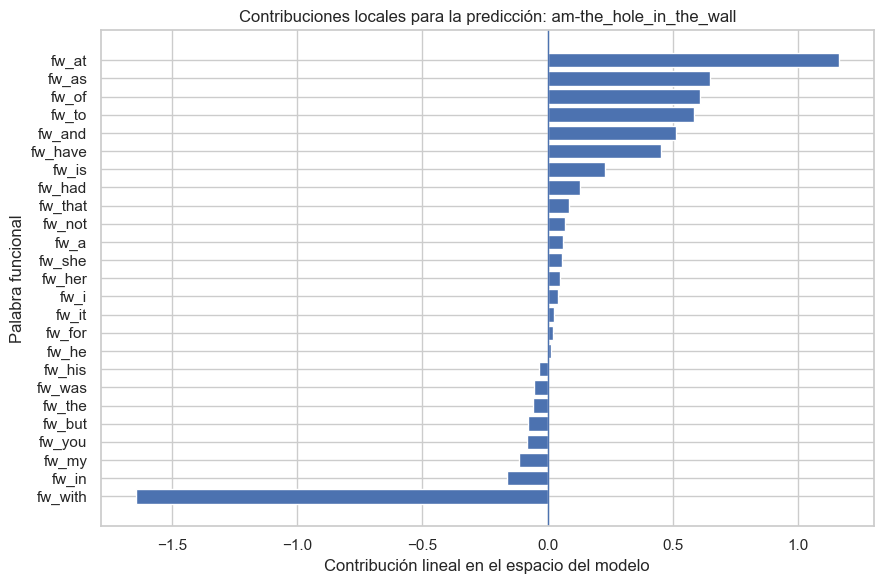

In [28]:
plot_local_contributions(
    local_df=local_df,
    work=work,
    save_path=FIGS_DIR / "mfw_lr_local_explanation_most_uncertain.png",
)

La obra `am-the_hole_in_the_wall` ha sido clasificada correctamente como de Arthur Morrison y la explicación local muestra que la variable con mayor impacto absoluto es `fw_with` que aparece con un valor transformado alto (`1.92`), pero como su coeficiente para Morrison es negativo (`-0.86`), su contribución es claramente contraria a la clase (`-1.65`). Es decir, el uso elevado de `with` en esta obra aleja al modelo de Arthur Morrison.

Aun así, varias variables compensan esa señal negativa y empujan con fuerza hacia Morrison. La más importante es `fw_at`, con una contribución positiva de `1.16`, coherente con que `at` era uno de los rasgos más característicos de Morrison en los coeficientes globales. También ayudan `fw_as`, `fw_and`, y algunas palabras cuyo valor transformado es bajo pero cuyo coeficiente negativo produce una contribución positiva, como `fw_of`, `fw_to`, `fw_have` y `fw_is`. En estos casos, no es la abundancia de la palabra lo que favorece a Morrison, sino precisamente su menor presencia relativa respecto al promedio aprendido por el modelo.

Así, la clasificación se apoya en un equilibrio donde `fw_with` tira fuertemente en contra, pero `fw_at`, `fw_as`, `fw_of`, `fw_to`, `fw_and` y `fw_have` aportan suficiente evidencia positiva para conseguir la predicción correcta.

Las demás variables tienen contribuciones bastante menores, por debajo de `0.20` en valor absoluto, por lo que actúan como ajustes secundarios. La lectura estilométrica sería que esta obra comparte el patrón fuerte de Morrison en `at` y `as`, aunque presenta un uso de `with` más parecido al perfil de otros autores, lo que la convierte en una predicción correcta pero localmente algo ambigua.

Vamos a analizar ahora una obra aleatoria del test.

In [29]:
rng = np.random.default_rng(SEED)
instance_id = rng.choice(X_test.index)
work = confidence_df.loc[instance_id, "work"]
predicted_author = confidence_df.loc[instance_id, "pred_author"]
true_author = confidence_df.loc[instance_id, "true_author"]

print(f"Instance ID: {instance_id}\nWork: {work}\nTrue Author: {true_author}\nPredicted Author: {predicted_author}")

local_df = local_linear_contributions(X_test_model_space, coef_df, instance_id, predicted_author)

local_df.to_csv(TABLES_DIR / f"mfw_lr_local_explanation_instance_{work}.csv", index=False)

local_df

Instance ID: 1
Work: akg-to_the_minute
True Author: anna_katharine_green
Predicted Author: anna_katharine_green


,feature,x_transformed,coefficient,contribution,abs_contribution
13,fw_had,1.570087,0.398430,0.625571,0.625571
0,fw_the,-1.050581,-0.531082,0.557945,0.557945
23,fw_not,0.768359,0.679110,0.521800,0.521800
15,fw_her,0.937688,0.479945,0.450038,0.450038
22,fw_she,0.868009,0.504062,0.437531,0.437531
21,fw_is,-0.864066,-0.410868,0.355017,0.355017
18,fw_for,1.036385,0.300777,0.311721,0.311721
12,fw_his,-1.314755,0.218198,-0.286877,0.286877
19,fw_but,0.430355,0.608602,0.261915,0.261915
17,fw_my,1.458681,0.154142,0.224845,0.224845


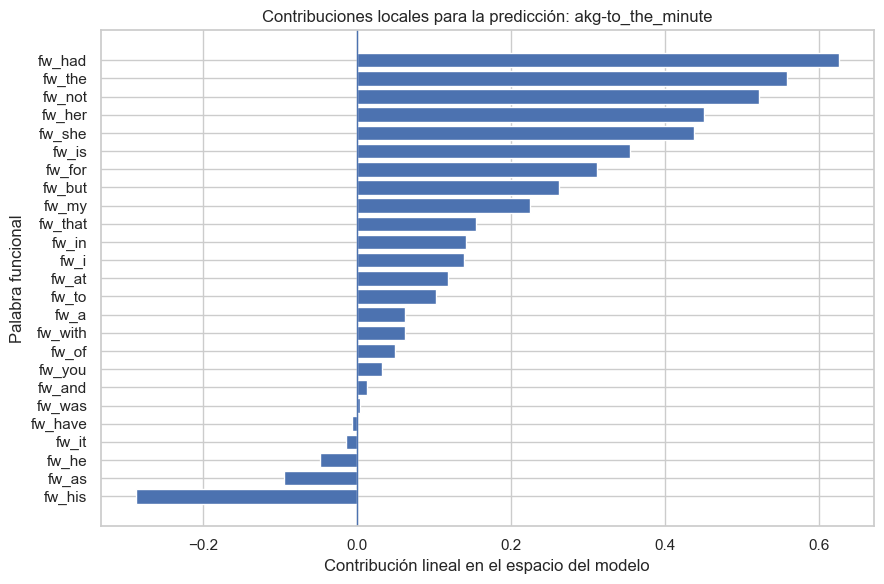

In [30]:
plot_local_contributions(
    local_df=local_df,
    work=work,
    save_path=FIGS_DIR / "mfw_lr_local_explanation_random.png",
)

La obra `akg-to_the_minute` ha sido clasificada correctamente como de Anna Katharine Green, y la explicación local muestra una predicción bastante coherente donde las principales contribuciones empujan en su mayoría hacia la autora real. La señal positiva más fuerte procede de `fw_had`, con una contribución de `0.63`, seguida de `fw_the`, `fw_not`, `fw_her` y `fw_she`. En el caso de `fw_the` y `fw_is`, lo interesante es que sus valores transformados son negativos y sus coeficientes también son negativos, por tanto, su menor presencia relativa favorece la clasificación como Anna Katharine Green.

El patrón más interpretable está en los pronombres y formas asociadas a la tercera persona femenina donde `fw_her` y `fw_she` aportan conjuntamente una señal clara a favor de la autora. Esto encaja con el perfil global que ya se observaba para Anna Katharine Green, donde `she` y `her` estaban entre las palabras funcionales con coeficiente positivo más alto. También `fw_not` y `fw_but` contribuyen positivamente, reforzando un perfil estilométrico compatible con el aprendido por el modelo para esta autora.

La principal señal en contra es `fw_his`, con una contribución de `-0.29`, ya que aunque su coeficiente para Anna Katharine Green es positivo, en esta obra aparece con un valor transformado bajo, por lo que resta evidencia a favor de la clase. También `fw_as`, `fw_he`, `fw_it` y `fw_have` empujan ligeramente en contra, pero con magnitudes pequeñas en comparación con las señales positivas dominantes.

En definitiva, la clasificación parece sólida y no depende de una única palabra funcional, sino de una combinación consistente de rasgos, especialmente `had`, `not`, `her`, `she` y la baja presencia relativa de `the` e `is`.

## Conclusiones

Este bloque genera automáticamente una síntesis breve a partir de las tablas calculadas a modo de resumen.

In [31]:
top_global = feature_importance_df.head(8)[
    ["feature", "importance_abs_mean", "top_positive_author", "top_negative_author"]
]
most_uncertain = confidence_df.head(3)

print("Palabras funcionales globalmente más influyentes por media de |coeficiente|:")
display(top_global)

print("\nPredicciones con menor margen de decisión:")
display(most_uncertain)

if len(high_corr_pairs) > 0:
    print("\nPares de features con alta correlación que conviene no interpretar de forma aislada:")
    display(high_corr_pairs.head(10))
else:
    print("\nNo se han detectado pares con |correlación Spearman| >= 0.70 en train.")

Palabras funcionales globalmente más influyentes por media de |coeficiente|:


,feature,importance_abs_mean,top_positive_author,top_negative_author
19,fw_but,0.523572,anna_katharine_green,wilkie_collins
20,fw_at,0.480334,arthur_morrison,gilbert_keith_chesterton
2,fw_to,0.472538,wilkie_collins,gilbert_keith_chesterton
6,fw_in,0.419637,wilkie_collins,richard_austin_freeman
12,fw_his,0.395532,arthur_conan_doyle,richard_austin_freeman
14,fw_with,0.364903,gilbert_keith_chesterton,arthur_morrison
0,fw_the,0.346641,richard_austin_freeman,anna_katharine_green
17,fw_my,0.340937,wilkie_collins,gilbert_keith_chesterton



Predicciones con menor margen de decisión:


,work,true_author,pred_author,proba_pred,proba_second,margin,is_correct
5,am-the_hole_in_the_wall,arthur_morrison,arthur_morrison,0.688619,0.164522,0.524097,True
3,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,0.696186,0.171868,0.524317,True
8,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,0.717890,0.187726,0.530163,True



Pares de features con alta correlación que conviene no interpretar de forma aislada:


,feature_1,feature_2,spearman_corr,abs_corr
397,fw_her,fw_she,0.960812,0.960812
117,fw_i,fw_my,0.872256,0.872256
140,fw_a,fw_her,-0.831325,0.831325
23,fw_the,fw_not,-0.798035,0.798035
147,fw_a,fw_she,-0.775534,0.775534
55,fw_to,fw_a,-0.770245,0.770245
72,fw_to,fw_she,0.759855,0.759855
65,fw_to,fw_her,0.758658,0.758658
212,fw_he,fw_his,0.704420,0.704420


A modo de síntesis, se deben tener en cuenta las siguientes conclusiones y limitaciones:

- Los coeficientes siguen siendo la explicación principal porque el modelo es una regresión logística y esto son interpretables, auditables y específicos por autor.
- La importancia global basada en coeficientes resume qué palabras funcionales separan más a los autores, pero no indica por sí sola si una palabra empuja hacia un autor concreto o contra él.
- La importancia por permutación ofrece un contraste model-agnostic, aunque debe leerse con prudencia por el tamaño reducido del test.
- Las explicaciones locales permiten revisar casos concretos, especialmente los de menor margen, donde la predicción es menos robusta.
- Las correlaciones entre palabras funcionales ayudan a evitar conclusiones demasiado literales sobre una única palabra.
- Dado que el conjunto de prueba tiene pocas muestras, sería recomendable repetir el análisis con validación cruzada estratificada o bootstrap si se quiere afirmar estabilidad estilométrica más allá de este split.